<a href="https://colab.research.google.com/github/motaeger/DigitalStrategy/blob/main/IBM_Attrition_Group_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Organizational Tenure and Employee Attrition among IBM Employees
**Research Methods for Business Analytics — Group Assignment**

**Members:** Isabela Castello (78487), ....

## Research Question
**What is the relationship between organizational tenure and employee attrition among IBM employees?**

## Hypotheses
**H1:** The relationship between organizational tenure and employee attrition is U-shaped: the likelihood of attrition decreases at lower levels of tenure but increases again at higher levels of tenure.

**H2:** Among longer-tenured employees, attrition is associated with time since last promotion, with employees who have gone longer without promotion exhibiting higher attrition rates.

## 1. Executive Summary
Complete this section after running the notebook. In one short paragraph, summarize the research question, the two methods, the main findings, whether H1 and H2 are supported, the practical implication, and the most important limitation.

## 2. Introduction
The analysis uses the IBM HR Analytics Employee Attrition & Performance dataset, consisting of 1,470 employee observations and 35 variables. The dataset contains employee characteristics relating to demographics, job characteristics, compensation, satisfaction, career history, and attrition. For this study, the focal variables are Attrition, YearsAtCompany, and YearsSinceLastPromotion.

Employee attrition is an important organizational issue because employee departures may involve replacement costs, loss of experience, and disruption to teams. Organizational tenure may relate to attrition nonlinearly: employees may become less likely to leave as they establish themselves in an organization, while attrition may rise again among some highly tenured employees.

A possible explanation for attrition among longer-tenured employees is career progression. Employees who have remained at the organization for many years but have also gone a long time without promotion may show different attrition patterns from employees who were promoted more recently.

### Variables
- **Attrition:** whether the employee left (`Yes`/`No`).
- **YearsAtCompany:** years worked at the organization; the measure of organizational tenure.
- **YearsSinceLastPromotion:** years since the employee's most recent promotion.

### Testing plan
- **H1:** quadratic logistic regression, because attrition is binary and H1 predicts a nonlinear relationship.
- **H2:** chi-square test of independence among longer-tenured employees, comparing attrition across categories of time since last promotion.

The analysis is associational rather than causal because the dataset is cross-sectional.

## 3. Data Preparation and Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency, chi2

file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(file_path)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
print("Number of employees:", df.shape[0])
print("Number of variables:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Number of employees: 1470
Number of variables: 35

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


### 3.1 Data-quality checks
We check missing values, duplicate observations, variable formats, and the ranges of the focal variables. Long-tenure observations are not automatically removed because they can be genuine observations and are important for testing H1.

In [ ]:
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
print("\nVariables with missing values:")
print(missing[missing > 0])
print("Number of duplicate rows:", df.duplicated().sum())

NameError: name 'df' is not defined

In [ ]:
print("YearsAtCompany range:",
      df["YearsAtCompany"].min(), "to", df["YearsAtCompany"].max())

print("YearsSinceLastPromotion range:",
      df["YearsSinceLastPromotion"].min(), "to",
      df["YearsSinceLastPromotion"].max())

inconsistent = df[
    df["YearsSinceLastPromotion"] > df["YearsAtCompany"]
]

print("Inconsistent observations:", len(inconsistent))

print("Rows where YearsSinceLastPromotion > YearsAtCompany:",
      len(inconsistent))

YearsAtCompany range: 0 to 40
YearsSinceLastPromotion range: 0 to 15
Inconsistent observations: 0
Rows where YearsSinceLastPromotion > YearsAtCompany: 0


#### Data Quality Assessment
The dataset contained no missing values or duplicate observations. The focal variables also showed plausible ranges, with organizational tenure ranging from 0 to 40 years and time since last promotion ranging from 0 to 15 years. Extreme tenure values were retained because they represent plausible employee histories and are particularly relevant for investigating a potential U-shaped tenure–attrition relationship. Therefore, no observations were removed from the dataset.

In [ ]:
# Convert Attrition to a binary variable
# 1 = employee left; 0 = employee stayed

df["Attrition_binary"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})


print(df[["Attrition", "Attrition_binary"]].head())

  Attrition  Attrition_binary
0       Yes                 1
1        No                 0
2       Yes                 1
3        No                 0
4        No                 0


### 3.2 Descriptive statistics

In [ ]:
df[["YearsAtCompany", "YearsSinceLastPromotion"]].describe()

,YearsAtCompany,YearsSinceLastPromotion
count,1470.000000,1470.000000
mean,7.008163,2.187755
std,6.126525,3.222430
min,0.000000,0.000000
25%,3.000000,0.000000
50%,5.000000,1.000000
75%,9.000000,3.000000
max,40.000000,15.000000



Attrition counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


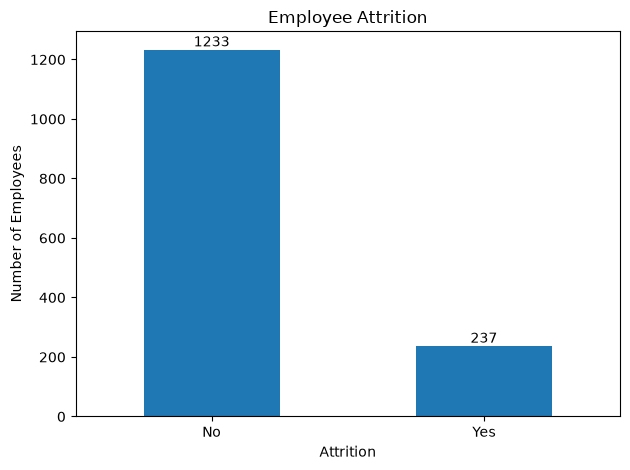

In [ ]:
attrition_counts = df["Attrition"].value_counts().reindex(["No", "Yes"])

print("\nAttrition counts:")
print(df["Attrition"].value_counts(dropna=False))

ax = attrition_counts.plot(kind="bar")
plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

for i, value in enumerate(attrition_counts):
    ax.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

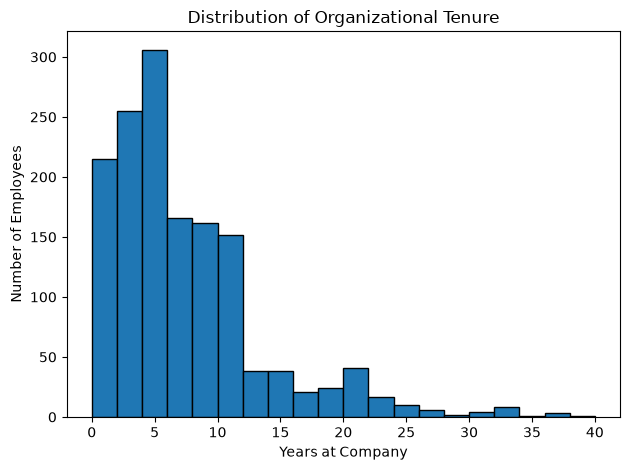

In [ ]:
plt.hist(df["YearsAtCompany"], bins=20, edgecolor="black")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.title("Distribution of Organizational Tenure")
plt.tight_layout()
plt.show()

### 3.3 Attrition across tenure
The observed attrition rate is calculated at each tenure level. We also inspect the number of employees at each level because rates based on very small groups can fluctuate substantially.

In [ ]:
tenure_summary = (
    df.groupby("YearsAtCompany")
      .agg(
          Employees=("Attrition_binary", "size"),
          Attritions=("Attrition_binary", "sum"),
          Attrition_Rate=("Attrition_binary", "mean")
      )
      .reset_index()
)

tenure_summary.head(15)

,YearsAtCompany,Employees,Attritions,Attrition_Rate
0,0,44,16,0.363636
1,1,171,59,0.345029
2,2,127,27,0.212598
3,3,128,20,0.156250
4,4,110,19,0.172727
5,5,196,21,0.107143
6,6,76,9,0.118421
7,7,90,11,0.122222
8,8,80,9,0.112500
9,9,82,8,0.097561


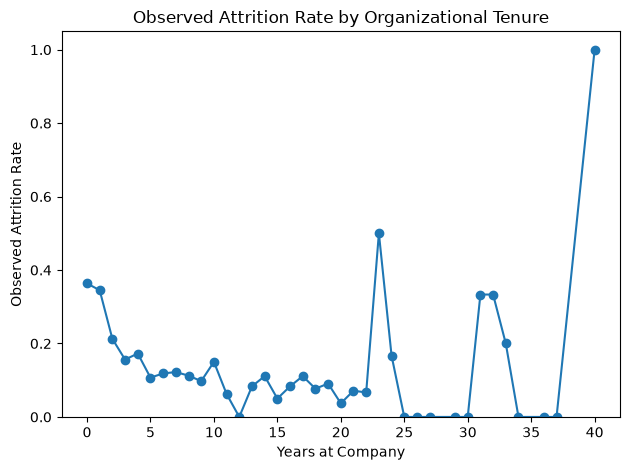

In [ ]:
plt.plot(
    tenure_summary["YearsAtCompany"],
    tenure_summary["Attrition_Rate"],
    marker="o"
)
plt.xlabel("Years at Company")
plt.ylabel("Observed Attrition Rate")
plt.title("Observed Attrition Rate by Organizational Tenure")
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

In [ ]:
# Observation counts at high tenure levels
tenure_summary.tail(15)

,YearsAtCompany,Employees,Attritions,Attrition_Rate
22,22,15,1,0.066667
23,23,2,1,0.500000
24,24,6,1,0.166667
25,25,4,0,0.000000
26,26,4,0,0.000000
27,27,2,0,0.000000
28,29,2,0,0.000000
29,30,1,0,0.000000
30,31,3,1,0.333333
31,32,3,1,0.333333


### 3.4 Distribution of Time Since Last Promotion

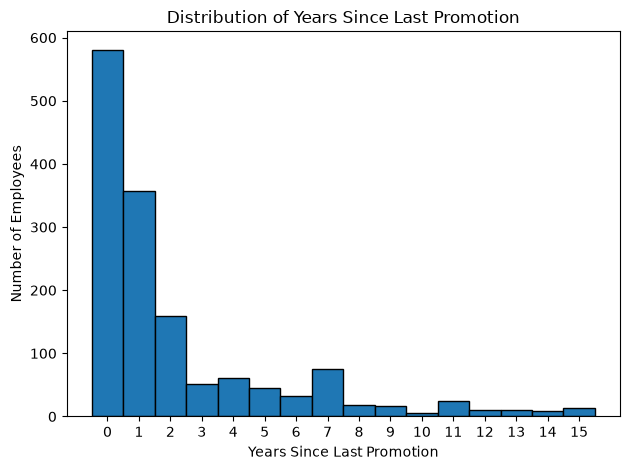

Average years since last promotion: 2.19
Median years since last promotion: 1.0


In [ ]:
plt.hist(
    df["YearsSinceLastPromotion"],
    bins=np.arange(-0.5, 16.5, 1),
    edgecolor="black"
)

plt.xlabel("Years Since Last Promotion")
plt.ylabel("Number of Employees")
plt.title("Distribution of Years Since Last Promotion")
plt.xticks(range(0, 16))

plt.tight_layout()
plt.show()

# Mean and median years since last promotion
avg_promotion = df["YearsSinceLastPromotion"].mean()
median_promotion = df["YearsSinceLastPromotion"].median()

print("Average years since last promotion:", round(avg_promotion, 2))
print("Median years since last promotion:", median_promotion)

### EDA interpretation
Complete after running the notebook. Discuss:
1. the overall attrition rate;
2. the distribution of tenure;
3. whether the descriptive tenure–attrition pattern appears linear or nonlinear; and
4. why high-tenure rates require caution when based on small groups.

Do not treat EDA alone as a hypothesis test.

The dataset contains 1,470 employees, of whom 237 experienced attrition and 1,233 remained with the company, corresponding to an overall attrition rate of 16.12%. Employees had worked at the company for an average of 7.01 years (SD = 6.13), with a median tenure of 5 years. The distribution of organizational tenure is strongly right-skewed, with most employees having relatively short to moderate tenure and comparatively few employees remaining at the company for more than 20 years.

The observed attrition rates suggest a nonlinear relationship between organizational tenure and attrition. Attrition is particularly high at the beginning of employees' tenure, decreasing from 36.4% at less than one year and 34.5% at one year to generally lower rates as tenure increases. At higher tenure levels, observed attrition rates become considerably more volatile. However, these values are based on very small numbers of employees. For example, the 50% attrition rate at 23 years is based on only two employees, while the 100% rate at 40 years represents a single employee. These fluctuations therefore provide limited descriptive evidence of increasing attrition at high tenure and should be interpreted cautiously. Whether the overall relationship is U-shaped, as proposed in H1, requires formal statistical testing.

Time since last promotion is also strongly right-skewed. Employees had gone an average of 2.19 years since their last promotion, compared with a median of 1 year, and the variable ranges from 0 to 15 years. Most employees were therefore concentrated at relatively low values of time since last promotion, while substantially fewer employees had gone many years without a promotion. This distribution describes the promotion history of the sample but does not by itself indicate whether time since last promotion is associated with attrition; this relationship is examined formally in the analysis of H2.

## 4. Method 1 — Quadratic Logistic Regression

### 4.1 Method selection
H1 predicts a U-shaped relationship between organizational tenure and attrition. Logistic regression is appropriate because attrition is binary. A squared tenure term allows the relationship to curve rather than imposing a straight-line association.

The model contains organizational tenure and organizational tenure squared. A pattern consistent with H1 requires a negative linear tenure coefficient and a positive quadratic coefficient. Statistical significance, model comparison, and predicted probabilities are considered together.

In [ ]:
# Baseline model: linear tenure relationship
model_linear = smf.logit(
    "Attrition_binary ~ YearsAtCompany",
    data=df
).fit()

print(model_linear.summary())

In [ ]:
# H1 model: quadratic tenure relationship
model_quadratic = smf.logit(
    "Attrition_binary ~ YearsAtCompany + I(YearsAtCompany**2)",
    data=df
).fit()

print(model_quadratic.summary())

In [ ]:
h1_results = pd.DataFrame({
    "Coefficient": model_quadratic.params,
    "Std_Error": model_quadratic.bse,
    "p_value": model_quadratic.pvalues
})

h1_results

### 4.2 Linear versus quadratic model
A likelihood-ratio test compares the linear model with the quadratic model. A significant result indicates that adding the quadratic term improves model fit relative to the simpler linear specification. AIC is also reported; lower AIC indicates better relative fit.

In [ ]:
lr_stat = 2 * (model_quadratic.llf - model_linear.llf)
df_diff = int(model_quadratic.df_model - model_linear.df_model)
lr_p = chi2.sf(lr_stat, df_diff)

print("Linear model AIC:", round(model_linear.aic, 3))
print("Quadratic model AIC:", round(model_quadratic.aic, 3))
print("Likelihood-ratio statistic:", round(lr_stat, 3))
print("Degrees of freedom:", df_diff)
print("Likelihood-ratio p-value:", round(lr_p, 6))

### 4.3 Estimated turning point
For a quadratic expression, the turning point is calculated from the linear and squared coefficients. Because the logistic transformation is monotonic, this corresponds to the turning point in predicted attrition probability. It is a model-based estimate, not an exact behavioral threshold.

In [ ]:
b1 = model_quadratic.params["YearsAtCompany"]
b2 = model_quadratic.params["I(YearsAtCompany ** 2)"]

turning_point = -b1 / (2 * b2)

print("Estimated turning point:",
      round(turning_point, 2),
      "years at the company")

### 4.4 Predicted attrition probabilities

In [ ]:
tenure_range = pd.DataFrame({
    "YearsAtCompany": np.arange(
        df["YearsAtCompany"].min(),
        df["YearsAtCompany"].max() + 1
    )
})

tenure_range["Predicted_Attrition"] = model_quadratic.predict(tenure_range)

plt.plot(
    tenure_range["YearsAtCompany"],
    tenure_range["Predicted_Attrition"],
    linewidth=2
)
plt.axvline(
    turning_point,
    linestyle="--",
    label=f"Estimated turning point = {turning_point:.1f} years"
)
plt.xlabel("Years at Company")
plt.ylabel("Predicted Probability of Attrition")
plt.title("Predicted Attrition Probability by Organizational Tenure")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

### 4.5 Assumptions and diagnostics
- **Binary dependent variable:** `Attrition_binary` takes values 0 and 1.
- **Independent observations:** each row represents one employee. Possible clustering within teams cannot be verified from this dataset.
- **Functional form:** H1 explicitly predicts nonlinearity, so a quadratic tenure term is included.
- **Successful estimation:** convergence is checked below.
- **Outcome variation:** counts of attrition and non-attrition observations are reported.

Normality of the predictor itself is not an assumption of logistic regression.

In [ ]:
print("Linear model converged:",
      model_linear.mle_retvals["converged"])
print("Quadratic model converged:",
      model_quadratic.mle_retvals["converged"])

print("\nOutcome counts:")
print(df["Attrition_binary"].value_counts())

### 4.6 H1 interpretation
Complete after running the model. Report the signs and p-values of the linear and squared tenure terms, the model comparison, the estimated turning point, and the predicted-probability pattern. Then state whether the evidence is consistent with H1. Do not use causal language.

## 5. Method 2 — Chi-Square Test of Independence

### 5.1 Method selection and operationalization
H2 examines whether attrition among longer-tenured employees is associated with time since last promotion. A chi-square test is appropriate because both variables are categorical in this analysis.

For the primary analysis, **10 or more years at the company** is defined in advance as longer tenure. Time since last promotion is grouped as:
- 0–1 years;
- 2–4 years;
- 5+ years.

These cutoffs are an operationalization chosen for interpretability, not naturally occurring thresholds. They should not be changed after seeing the results merely to obtain statistical significance.

In [ ]:
LONG_TENURE_CUTOFF = 10

long_tenure = df[
    df["YearsAtCompany"] >= LONG_TENURE_CUTOFF
].copy()

print("Longer-tenured employees:", len(long_tenure))
print("Share of full sample:",
      round(len(long_tenure) / len(df) * 100, 2), "%")

In [ ]:
long_tenure["PromotionDelay"] = pd.cut(
    long_tenure["YearsSinceLastPromotion"],
    bins=[-1, 1, 4, np.inf],
    labels=["0–1 years", "2–4 years", "5+ years"]
)

print(long_tenure["PromotionDelay"].value_counts().sort_index())

In [ ]:
promotion_table = pd.crosstab(
    long_tenure["PromotionDelay"],
    long_tenure["Attrition"]
).reindex(columns=["No", "Yes"])

promotion_table

### 5.2 Descriptive attrition rates

In [ ]:
promotion_rates = (
    long_tenure
    .groupby("PromotionDelay", observed=False)
    .agg(
        Employees=("Attrition_binary", "size"),
        Attritions=("Attrition_binary", "sum"),
        Attrition_Rate=("Attrition_binary", "mean")
    )
)

promotion_rates["Attrition_Percent"] = (
    promotion_rates["Attrition_Rate"] * 100
)

promotion_rates

In [ ]:
ax = promotion_rates["Attrition_Percent"].plot(kind="bar")
plt.xlabel("Time Since Last Promotion")
plt.ylabel("Attrition Rate (%)")
plt.title(
    "Attrition by Time Since Last Promotion\n"
    f"Employees with {LONG_TENURE_CUTOFF}+ Years at Company"
)
plt.xticks(rotation=0)

for i, value in enumerate(promotion_rates["Attrition_Percent"]):
    ax.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### 5.3 Chi-square test and expected counts

In [ ]:
chi2_stat, h2_p, dof, expected = chi2_contingency(promotion_table)

expected_counts = pd.DataFrame(
    expected,
    index=promotion_table.index,
    columns=promotion_table.columns
)

print("Chi-square statistic:", round(chi2_stat, 3))
print("Degrees of freedom:", dof)
print("p-value:", round(h2_p, 6))
print("\nExpected cell counts:")
print(expected_counts.round(2))
print("\nMinimum expected count:",
      round(expected_counts.min().min(), 2))

The expected-count table is inspected before interpreting the chi-square result because the chi-square approximation relies on sufficiently large expected cell counts.

### 5.4 Effect size — Cramér's V

In [ ]:
n = promotion_table.to_numpy().sum()
min_dim = min(
    promotion_table.shape[0] - 1,
    promotion_table.shape[1] - 1
)

cramers_v = np.sqrt(chi2_stat / (n * min_dim))

print("Cramér's V:", round(cramers_v, 3))

### 5.5 H2 interpretation
Complete after running the analysis. Describe the attrition percentages across promotion-delay groups, then report the chi-square statistic, degrees of freedom, p-value, Cramér's V, and expected-count check.

If the p-value is not significant, distinguish a descriptive difference from statistical evidence. Because this method conditions on employees with 10+ years of tenure, it tests an association within longer-tenured employees; it is not a formal moderation test.

## 6. Supplementary Analysis — Formal Moderation Test

The original theoretical formulation of H2 proposed that time since last promotion **moderates** the tenure–attrition relationship. A formal moderation claim requires an interaction term. The following logistic regression is therefore included as a supplementary robustness analysis, not as the assignment's second primary method.

In [ ]:
moderation_formula = (
    "Attrition_binary ~ YearsAtCompany "
    "+ I(YearsAtCompany**2) "
    "+ YearsSinceLastPromotion "
    "+ YearsAtCompany:YearsSinceLastPromotion"
)

moderation_model = smf.logit(
    moderation_formula,
    data=df
).fit()

print(moderation_model.summary())

In [ ]:
moderation_results = pd.DataFrame({
    "Coefficient": moderation_model.params,
    "Std_Error": moderation_model.bse,
    "p_value": moderation_model.pvalues
})

moderation_results

### Supplementary-analysis interpretation
Complete after running the model. Focus on `YearsAtCompany:YearsSinceLastPromotion`. State whether it provides evidence that the association between tenure and attrition changes as time since last promotion increases. Keep this discussion shorter than the two primary analyses.

## 7. Reflection on AI Use

AI tools were used as support during project development, while the group remained responsible for the research design, statistical decisions, execution, verification, and final interpretation.

| AI use | Example | Group contribution beyond AI |
|---|---|---|
| Research-question development | Brainstormed feasible IBM HR questions | Evaluated relevance and selected the tenure question |
| Method selection | Asked how to test a U-shaped relationship with a binary outcome | Verified quadratic logistic regression against course concepts |
| Assignment design | Asked how H2 could use a different statistical method | Identified that two logistic regressions would not satisfy the assignment and redesigned the primary H2 test |
| Python support | Used AI to help structure data checks, models, and plots | Ran, checked, simplified, and interpreted the code |
| Critical evaluation | Asked for possible limitations | Retained only limitations applicable to the dataset and design |

### Example prompts
- “How can we test whether organizational tenure and attrition have a U-shaped relationship when attrition is binary?”
- “How can we test a second hypothesis about years since last promotion using a different statistical method?”
- “What assumptions should we check for quadratic logistic regression and a chi-square test?”

### Critical reflection
An important limitation of relying on AI was that an initially natural suggestion was to test both hypotheses using logistic regression. Although statistically plausible, that design would not satisfy the assignment requirement that the two primary methods be different. The group therefore evaluated the suggestion against the assignment instructions and redesigned the second primary analysis. AI output was treated as a starting point rather than evidence; conclusions were based on the actual outputs and the group's interpretation.

## 8. Conclusion

Complete after running all analyses.

A strong conclusion should:
1. answer the research question;
2. state separately whether H1 and H2 are supported;
3. connect the findings into one coherent story;
4. discuss practical implications cautiously;
5. acknowledge the main limitations.

### Limitations
- Cross-sectional data do not establish causality.
- The dataset does not establish that the sample is representative of all IBM employees or employees generally.
- Very high tenure levels contain relatively few observations, creating more uncertainty on the right side of the estimated curve.
- `YearsSinceLastPromotion` does not indicate whether an employee wanted, expected, or was eligible for promotion; it should not automatically be interpreted as being “passed over.”
- Potential confounders such as age, job level, overtime, income, job role, and job satisfaction are not included in the primary tests.

Use **relationship**, **association**, and **predicted probability**, rather than causal terms such as **effect** or **impact**.

## 9. References
Add the dataset source and all academic or methodological sources used in the final submission, following the citation style required by the course.